> 시험범위 pandas~machine learning (numpy를 사용하는 게 나올 수 있음... 당연히...)

- precision: 스팸이라고 분류한 것 중 몇개가 진짜인가
- recall: actual spam 개수 중 몇개나 찾아냈는가 (무조건 스팸 아닙니다 하는 건 true positive=0, recall=0)


- class개 3개인 경우: 똑같이 3x3 confusion matrix 만들면 된다. -> nxn confusion matrx.
- 각 class에 대해 precision, recall 구한 다음 평균을 구한다.

# 평가 지수
||Predicted Spam|Not Predicted Spam|
|---|---|---|
|**Actual Spam**|TP|FN|
|**Not Actual Spam**|FP|TN|

# KNN (K-Nearest-Neighbors)
- 가까운 점 k개의 클래스를 확인해서 가장 개수가 많은 클래스를 선택한다.
  - 데이터 테이블의 각 row가 벡터가 되고, 벡터간의 거리 구한다.
- Regression에서도 쓸 수 있다. 가장 가까운 k개 점의 평균을 내면...

## 어떤 K를 골라야 하나?
- 데이터셋마다 다를 수 있다.
- K=1,2,3,..N까지 실험해보고 정확도가 가장 높은 걸로 고른다.

- 사람이 정해줘야 하는 파라미터를 hyperparameter라고 한다. K는 hyperparameter.
- 그냥 parameter는 모델의 알고리즘이 결정한다.

# Classification on Iris using KNN

In [139]:
from sklearn import datasets

iris = datasets.load_iris()
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [140]:
X, Y = iris.data, iris.target # input features, targets
print(X.shape, Y.shape)
print(iris.feature_names)
print(iris.target_names)
print(X[:10])

(150, 4) (150,)
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]


In [141]:
from sklearn.preprocessing import StandardScaler

# Y는 클래스이기 때문에 standardization할 필요 없다.
sc_X = StandardScaler()
X_std = sc_X.fit_transform(X)
print(f'X_mean={X_std.mean():.4f}, X_std={X_std.std():.4f}')

X_mean=-0.0000, X_std=1.0000


In [142]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y, test_size=0.3)

print(X_train.shape, X_test.shape)
print(Y_train.shape, Y_test.shape)

(105, 4) (45, 4)
(105,) (45,)


In [143]:
# model setting
from sklearn import neighbors
from my_knn import MyKNeighborsClassifier

# K=n_neighbors
model = MyKNeighborsClassifier(n_neighbors=5)
model2 = neighbors.KNeighborsClassifier(n_neighbors=5)

In [144]:
# 데이터간 거리 계산만 하면 돼서
# fit에서 하는 일이 없다
# train data 그대로 들고 있는다 ㅋ ㅋ
model.fit(X_train, Y_train)
model2.fit(X_train, Y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](3,)","[0,1,2]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [145]:
# print(Y_train.shape)
Y_pred = model.predict(X_test)
Y_pred2 = model2.predict(X_test)

print('MyKNeighborsClassifier')
for y1, y2 in zip(Y_test, Y_pred):
    print(y1, y2)

print('KNeighborsClassifier')
for y1, y2 in zip(Y_test, Y_pred2):
    print(y1, y2)

MyKNeighborsClassifier
2 2
1 1
1 1
1 1
1 1
0 0
1 1
2 2
2 2
1 1
0 0
2 2
1 2
0 0
0 0
1 1
1 1
2 2
2 2
0 0
0 0
2 2
1 1
1 1
0 0
0 0
1 1
1 1
0 0
2 2
2 2
0 0
1 1
0 0
1 1
1 1
0 0
2 2
1 1
2 2
1 1
1 1
0 0
1 1
2 2
KNeighborsClassifier
2 2
1 1
1 1
1 1
1 1
0 0
1 1
2 2
2 2
1 1
0 0
2 2
1 2
0 0
0 0
1 1
1 1
2 2
2 2
0 0
0 0
2 2
1 1
1 1
0 0
0 0
1 1
1 1
0 0
2 2
2 2
0 0
1 1
0 0
1 1
1 1
0 0
2 2
1 1
2 2
1 1
1 1
0 0
1 1
2 2


In [146]:
from sklearn.metrics import accuracy_score, \
        confusion_matrix,\
        precision_score, recall_score, f1_score

# 평가 지수
||Predicted Spam|Not Predicted Spam|
|---|---|---|
|**Actual Spam**|TP|FN|
|**Not Actual Spam**|FP|TN|

In [147]:
# train-test split에서 randomness가 적용되기에 평가 지표도 조금씩 다를 수 있다.
print(f'confusion matrix:\n\
    {confusion_matrix(Y_test, Y_pred)}\n\
    {confusion_matrix(Y_test, Y_pred2)}')

print(f'accuracy_score=\n\
    {accuracy_score(Y_test, Y_pred) * 100:.4f}%\n\
    {accuracy_score(Y_test, Y_pred2):.4f}%')
# average=None, class별로 값을 따로 보겠다
# average=macro, 각 class의 평가점수의 평균.
print(f'precision=\n\
    {precision_score(Y_test, Y_pred, average=None)}\n\
    {precision_score(Y_test, Y_pred2, average=None)}')
print(f'recall=\n\
    {recall_score(Y_test, Y_pred, average=None)}\n\
    {recall_score(Y_test, Y_pred2, average=None)}')
print(f'f1=\n\
    {f1_score(Y_test, Y_pred, average=None)}\n\
    {f1_score(Y_test, Y_pred2, average=None)}')

print(f'precision=\n\
    {precision_score(Y_test, Y_pred, average='macro') * 100:.4f}%\n\
    {precision_score(Y_test, Y_pred2, average='macro') * 100:.4f}')
print(f'recall=\n\
    {recall_score(Y_test, Y_pred, average='macro') * 100:.4f}%\n\
    {recall_score(Y_test, Y_pred2, average='macro') * 100:.4f}%')
print(f'f1=\n\
    {f1_score(Y_test, Y_pred, average='macro') * 100:.4f}%\n\
    {f1_score(Y_test, Y_pred2, average='macro') * 100:.4f}%')

confusion matrix:
    [[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]
    [[13  0  0]
 [ 0 19  1]
 [ 0  0 12]]
accuracy_score=
    97.7778%
    0.9778%
precision=
    [1.         1.         0.92307692]
    [1.         1.         0.92307692]
recall=
    [1.   0.95 1.  ]
    [1.   0.95 1.  ]
f1=
    [1.         0.97435897 0.96      ]
    [1.         0.97435897 0.96      ]
precision=
    97.4359%
    97.4359
recall=
    98.3333%
    98.3333%
f1=
    97.8120%
    97.8120%


# practice

In [148]:
import pandas as pd

df = pd.read_csv('AmesHousing.txt', sep='\t')
df.sample(5)

df[['Gr Liv Area', 'SalePrice']].isna().sum()

Gr Liv Area    0
SalePrice      0
dtype: int64

In [149]:
X = df['Gr Liv Area'].values.reshape(-1, 1)
Y = df['SalePrice'].values.reshape(-1, 1)

In [150]:
from sklearn.preprocessing import StandardScaler

sc_X = StandardScaler()
sc_Y = StandardScaler()

X_std = sc_X.fit_transform(X)
Y_std= sc_Y.fit_transform(Y)

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X_std, Y_std, test_size=0.3)

In [156]:
from sklearn import neighbors
from my_knn import MyKNeighborsRegressor
from sklearn import linear_model

model1 = neighbors.KNeighborsRegressor(n_neighbors=6)
model2 = MyKNeighborsRegressor(n_neighbors=6)
model3 = linear_model.LinearRegression()

model1.fit(X_train, Y_train)
model2.fit(X_train, Y_train)
model3.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.73]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[0.01]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[44.85]


In [157]:
Y_pred1 = model1.predict(X_test)
Y_pred2 = model2.predict(X_test)
Y_pred3 = model3.predict(X_test)

print(Y_test.shape)
print(Y_pred1.shape)
print(Y_pred2.shape)
print(Y_pred3.shape)

(879, 1)
(879, 1)
(879, 1)
(879, 1)


In [158]:
from sklearn.metrics import r2_score

r2_1 = r2_score(Y_test, Y_pred1)
r2_2 = r2_score(Y_test, Y_pred2)
r2_3 = r2_score(Y_test, Y_pred3)

print(f'r2={r2_1:.4f}, {r2_2:.4f}, {r2_3}')

r2=0.4134, 0.4083, 0.4761395615838607


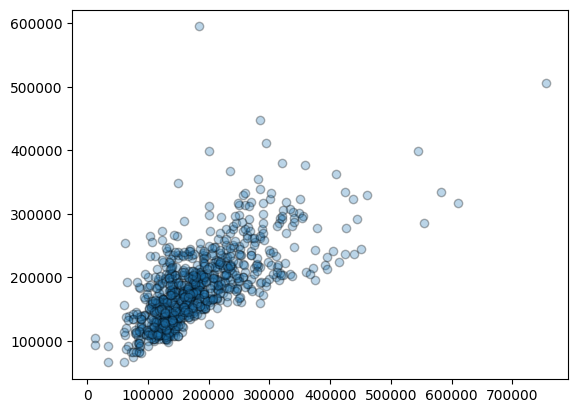

In [160]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
# ax.scatter(sc_Y.inverse_transform(Y_test), sc_Y.inverse_transform(Y_pred1), alpha=0.3)
# ax.scatter(sc_Y.inverse_transform(Y_test), sc_Y.inverse_transform(Y_pred2), alpha=0.3)
ax.scatter(sc_Y.inverse_transform(Y_test), sc_Y.inverse_transform(Y_pred3), \
           alpha=0.3, edgecolors='k')
plt.show()